# Eigenmode analysis: the pillbox cavity

The pillbox — a plain cylindrical cavity — is the one geometry whose resonant
spectrum is known in closed form, so it is the natural place to both *learn* the
eigenmode API and *check* that the solver is telling the truth.

This notebook is live: every figure below is produced by running `cavsim2d`.

We will

1. build the cavity and look at its geometry and mesh,
2. solve for the fundamental mode and plot its field,
3. collect the results into a `DataFrame` with `eigenmode.qois_df`, and
4. solve the first **100 modes** for azimuthal orders $m = 0 \dots 8$ and compare
   every one of them against the analytic spectrum.

## The physics in one paragraph

For an axisymmetric cavity the fields separate in the azimuthal angle $\varphi$,
so each mode carries an integer **azimuthal order** $m$ — $m=0$ is the *monopole*
(accelerating) family, $m=1$ the *dipole* (deflecting) family, and so on. For each
$m$ the modes split into **TM** ($H_z = 0$, these accelerate) and **TE**
($E_z = 0$, these do not). `cavsim2d` solves all of them with a single
product-space formulation, so the monopole TE modes are there too — see
[Theory](../../theory).

For a pillbox of radius $R$ and length $L$ the frequencies are exactly

$$
f_{mnp} = \frac{c}{2\pi}\sqrt{\left(\frac{\chi_{mn}}{R}\right)^2 + \left(\frac{p\pi}{L}\right)^2}
$$

with $\chi_{mn}$ the $n$-th zero of $J_m$ for TM modes ($p \ge 0$), and of $J_m'$
for TE modes ($p \ge 1$).

In [1]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn_zeros, jnp_zeros

from cavsim2d import Pillbox
from cavsim2d.utils.style import apply_style, WARM

apply_style()          # the house publication style

## 1. Build the cavity

A pillbox is a single-cell `Pillbox` — a closed PEC cylinder of radius `R` and length `L` (a 1 mm axis aperture keeps the monopole boundary condition clean).

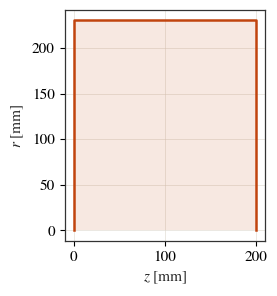

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [2]:
R, L = 230.0, 200.0            # mm
cav = Pillbox(1, [L, R, 1.0, 0.0, 0.0], beampipe='none')  # closed cylinder
cav.name = 'pillbox'

# A cavity analysed on its own writes its results to a workspace folder. Point it
# at a temporary one so running these docs leaves nothing behind; drop this line
# and it lands in ./pillbox/ next to you, ready for cav.save(...).
cav.set_workspace(os.path.join(tempfile.mkdtemp(), 'pillbox'))

cav.plot('geometry')

## 2. Solve for the fundamental

`cav.eigenmode.run(...)` takes a config dict. The defaults are sensible, so we only
set what we care about: the monopole family, a handful of modes, and the mesh
(element size `h` in mm and polynomial order `p`).

In [3]:
cav.eigenmode.run({
    'polarisation': 'monopole',
    'n_modes': 5,
    'boundary_conditions': 'mm',
    'mesh_config': {'h': 15, 'p': 3},
})

qois = cav.eigenmode.qois
print(f"fundamental : {qois['freq [MHz]']:.3f} MHz")
print(f"R/Q         : {qois['R/Q [Ohm]']:.2f} Ohm")
print(f"Q           : {qois['Q []']:.0f}")
print(f"Epk/Eacc    : {qois['Epk/Eacc []']:.3f}")

fundamental : 498.881 MHz
R/Q         : 218.69 Ohm
Q           : 36652
Epk/Eacc    : 3.005


The analytic TM$_{010}$ frequency of this pillbox is $c\,\chi_{01}/(2\pi R)$ — let us
check it, and then look at the mesh the solver actually used and the field it found.

In [4]:
c0 = 299792458.0
f_TM010 = c0 * jn_zeros(0, 1)[0] / (2 * np.pi * R * 1e-3) * 1e-6
print(f"analytic TM010 : {f_TM010:.3f} MHz")
print(f"cavsim2d       : {qois['freq [MHz]']:.3f} MHz")
print(f"relative error : {abs(qois['freq [MHz]'] - f_TM010) / f_TM010:.2e}")

analytic TM010 : 498.881 MHz
cavsim2d       : 498.881 MHz
relative error : 1.32e-07


In [5]:
cav.show_mesh()

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [6]:
# the accelerating field of the fundamental: |E| peaks on axis, as it must
cav.show_fields(mode=0, which='E')

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

## 3. Results as a table: `qois_df`

`cav.eigenmode.qois` gives the fundamental, and `cav.eigenmode.mpole_qois(pol)` gives
a dict per polarisation — handy for lookups, awkward for plotting. **`cav.eigenmode.qois_df`**
returns *every* mode of *every* solved polarisation as a single `DataFrame`, so the
results filter and plot like any other table.

Each row carries all the QOIs plus

| column | meaning |
| --- | --- |
| `m` | azimuthal order (0 monopole, 1 dipole, …) |
| `polarisation` | its name |
| `mode` | mode index within that polarisation |
| `mode_index` | `'<m>-<mode>'`, e.g. `'0-0'` = monopole fundamental |

In [7]:
df = cav.eigenmode.qois_df
df[['mode_index', 'polarisation', 'mode', 'freq [MHz]', 'R/Q [Ohm]', 'Q []']]

,mode_index,polarisation,mode,freq [MHz],R/Q [Ohm],Q []
0,0-0,monopole,0,498.880622,2.186857e+02,36651.671630
1,0-1,monopole,1,900.335453,3.085170e+01,32078.454773
2,0-2,monopole,2,1092.504778,4.567414e-12,72348.326309
3,0-3,monopole,3,1145.139395,2.666466e+01,55531.233510
4,0-4,monopole,4,1368.600395,8.725004e+01,39548.824898
5,0-5,monopole,5,1579.825966,5.162120e+00,42488.659340
6,0-6,monopole,6,1637.037198,6.084898e-07,112154.352392


## 4. The whole spectrum: 100 modes, $m = 0 \dots 8$

Now the real test. We ask for the first 100 modes of each azimuthal order from the
monopole up to $m=8$ — 900 modes in total — in **one** call, by passing a list of
azimuthal orders as the polarisation.

This takes a few minutes.

In [8]:
cav.eigenmode.run({
    'polarisation': list(range(9)),      # m = 0, 1, ..., 8
    'n_modes': 100,
    'rerun': True,
    'boundary_conditions': 'mm',
    'mesh_config': {'h': 25, 'p': 3},
})

df = cav.eigenmode.qois_df
print(f"{len(df)} modes across {df['polarisation'].nunique()} polarisations")

918 modes across 9 polarisations


The closed-form spectrum, for comparison — TM ($p \ge 0$) and TE ($p \ge 1$) merged
and sorted, exactly as the solver returns them:

In [9]:
def analytic_modes(m, R_mm, L_mm, n_modes):
    '''Lowest *n_modes* pillbox frequencies [MHz] for azimuthal order m.'''
    Rm, Lm = R_mm * 1e-3, L_mm * 1e-3
    f = []
    for chi in jn_zeros(m, 20):                    # TM_mnp, p >= 0
        f += [c0 / (2 * np.pi) * np.hypot(chi / Rm, p * np.pi / Lm) * 1e-6
              for p in range(0, 20)]
    for chi in jnp_zeros(m, 20):                   # TE_mnp, p >= 1
        f += [c0 / (2 * np.pi) * np.hypot(chi / Rm, p * np.pi / Lm) * 1e-6
              for p in range(1, 20)]
    return np.sort(f)[:n_modes]

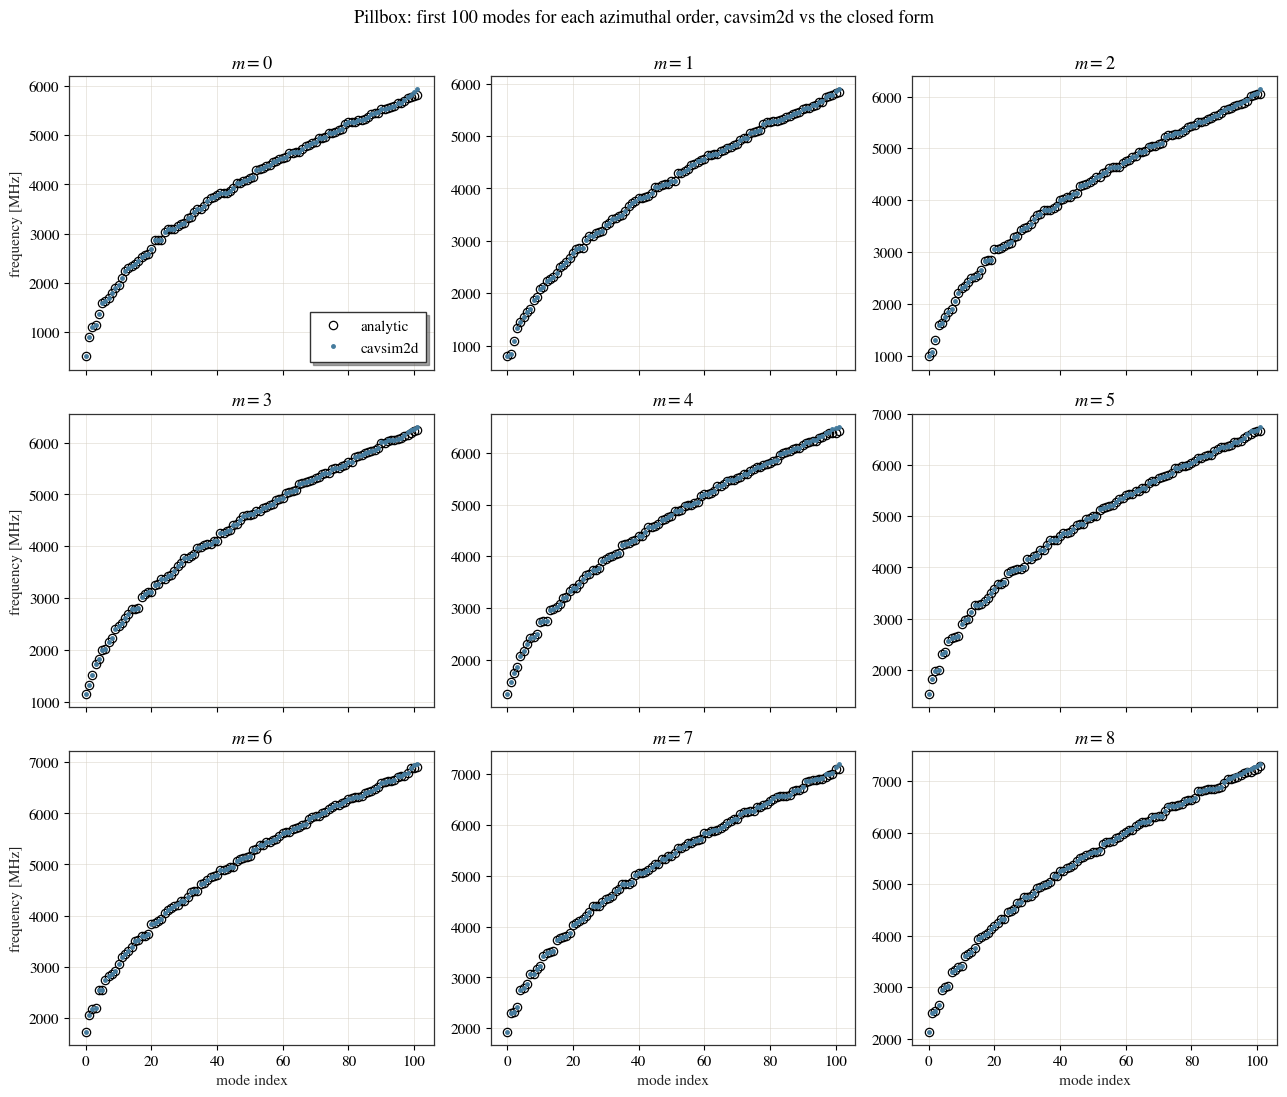

In [10]:
fig, axs = plt.subplots(3, 3, figsize=(13, 11), sharex=True)

for m, ax in zip(range(9), axs.ravel()):
    num = df[df['m'] == m].sort_values('freq [MHz]')['freq [MHz]'].to_numpy()
    ana = analytic_modes(m, R, L, len(num))
    idx = np.arange(len(num))

    ax.plot(idx, ana, lw=0, marker='o', ms=6, mfc='none', mec='k', mew=0.9,
            label='analytic')
    ax.plot(idx, num, lw=0, marker='o', ms=2.5, color=WARM[0], label='cavsim2d')
    ax.set_title(f'$m = {m}$')

for ax in axs[-1]:
    ax.set_xlabel('mode index')
for ax in axs[:, 0]:
    ax.set_ylabel('frequency [MHz]')
axs[0, 0].legend(loc='lower right')
fig.suptitle('Pillbox: first 100 modes for each azimuthal order, '
             'cavsim2d vs the closed form', y=0.995)
fig.tight_layout()
plt.show()

The agreement holds right across the spectrum. It is not *uniform*, though, and it is worth
being precise about why: the fundamental matches to ~$10^{-10}$, but the error grows with mode
number, reaching about a percent by mode 100. Nothing is wrong — a fixed mesh simply has far
fewer elements per wavelength for the 100th mode than for the first. Refine the mesh (lower `h`,
raise `p`, or use `cav.study_mesh_convergence`) and the whole curve tightens.


In [11]:
for m in range(9):
    num = df[df['m'] == m].sort_values('freq [MHz]')['freq [MHz]'].to_numpy()[:100]
    ana = analytic_modes(m, R, L, len(num))
    err = np.abs(num - ana) / ana
    print(f"m = {m}:  max relative error over {len(num)} modes = {err.max():.2e}")

m = 0:  max relative error over 100 modes = 7.88e-03
m = 1:  max relative error over 100 modes = 3.83e-03
m = 2:  max relative error over 100 modes = 5.60e-03
m = 3:  max relative error over 100 modes = 9.79e-03
m = 4:  max relative error over 100 modes = 1.31e-02
m = 5:  max relative error over 100 modes = 9.07e-03
m = 6:  max relative error over 100 modes = 6.48e-03
m = 7:  max relative error over 100 modes = 8.35e-03
m = 8:  max relative error over 100 modes = 9.24e-03


## 5. Which modes actually accelerate?

A physical payoff that falls straight out of the table. $R/Q$ measures how strongly a
mode accelerates a beam on axis. **TE modes have no $E_z$, so they cannot accelerate**
— and this is true for the monopole TE modes as much as the dipole ones. Colour the
monopole spectrum by $R/Q$ and the TE modes drop out at zero:

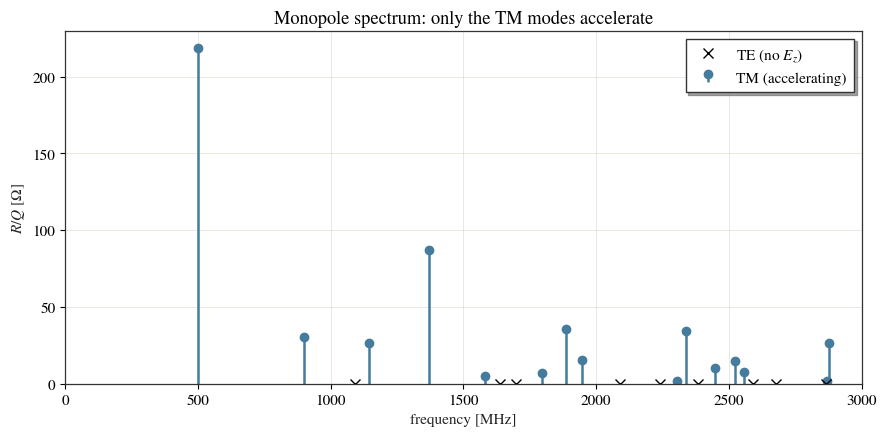

39 of 102 monopole modes are TE (R/Q = 0)


In [12]:
mono = df[df['m'] == 0].sort_values('freq [MHz]')
is_te = mono['R/Q [Ohm]'] < 1e-6          # TE: no longitudinal field

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.stem(mono.loc[~is_te, 'freq [MHz]'], mono.loc[~is_te, 'R/Q [Ohm]'],
        basefmt=' ', linefmt=WARM[0], markerfmt='o', label='TM (accelerating)')
ax.plot(mono.loc[is_te, 'freq [MHz]'], np.zeros(is_te.sum()),
        lw=0, marker='x', ms=7, color='k', label='TE (no $E_z$)')

ax.set_xlim(0, 3000)
ax.set_ylim(bottom=0)
ax.set_xlabel('frequency [MHz]')
ax.set_ylabel(r'$R/Q$ [$\Omega$]')
ax.set_title('Monopole spectrum: only the TM modes accelerate')
ax.legend()
fig.tight_layout()
plt.show()

print(f"{is_te.sum()} of {len(mono)} monopole modes are TE (R/Q = 0)")

Those TE crosses are worth a second look: an $(E_r, E_z)$-only formulation has no
azimuthal unknown at all, so a purely azimuthal $E_\varphi$ field is *invisible* to it —
the monopole TE modes are not merely inaccurate, they are absent. `cavsim2d` solves
every $m$ on the same product space, so they are simply there, and correctly report
$R/Q = 0$.

## Where to go next

- [Eigenmode](../../eigenmode) — the full configuration reference.
- [Theory](../../theory) — the weak form behind the solver.
- `cav.study_mesh_convergence(...)` — adaptive mesh refinement and error-vs-DOF convergence.
- `cav.plot_dispersion(...)` — Brillouin diagrams for multi-cell cavities.